# Feature Engineering Pipeline cho Sales Forecasting

Notebook này thực hiện đầy đủ **5 bước Feature Engineering** theo quy trình chuẩn:

| Bước | Nội dung | Mục tiêu |
| :---: | :--- | :--- |
| 1 | **Aggregation & Alignment** | Gom tất cả bảng dữ liệu về mức ngày để tạo bảng Master |
| 2 | **Feature Creation** | Tạo 6 nhóm đặc trưng: Time, Lag, Rolling, Promo, Enrichment, Inventory |
| 3 | **Data Leakage Prevention** | Đảm bảo Lag/Rolling chỉ nhìn vào quá khứ |
| 4 | **Feature Selection** | Loại bỏ đặc trưng thừa, phát hiện rò rỉ dữ liệu |
| 5 | **Iterative Validation** | Đánh giá chéo chuỗi thời gian (Time-Series CV) |

> **Lưu ý quan trọng:** Bài toán này dự báo cho giai đoạn **01/01/2023 – 01/07/2024**, trong khi tất cả dữ liệu giao dịch phụ trợ (orders, inventory, web_traffic) chỉ có đến **31/12/2022**. Vì vậy, chúng ta phải phân biệt rõ:
> - **Projectable Features** ✅ (có thể tính cho tương lai): Calendar, Trend, Projected Promo
> - **Historical-Only Features** ⚠️ (chỉ dùng được cho giai đoạn huấn luyện): Lag Revenue, Order counts, Inventory, Web traffic

## Khởi tạo Môi trường

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = r'./datathon-2026-round-1'
print('Sẵn sàng!')

Sẵn sàng!


---
## Bước 1: Định Hình Tập Dữ Liệu Master (Aggregation & Alignment)

Chúng ta gom dữ liệu từ **7 bảng nguồn** về cùng mức chi tiết **ngày (daily)**, sau đó ghép nối (merge) tất cả vào bảng xương sống `sales.csv`.

```
sales.csv (backbone: Date, Revenue, COGS)
  ├── orders.csv + order_items.csv + products.csv + geography.csv  →  Enrichment hàng ngày
  ├── web_traffic.csv  →  Lượng truy cập web hàng ngày
  ├── inventory.csv  →  Tình trạng tồn kho hàng tháng (map về ngày)
  └── promotions.csv  →  Lịch khuyến mãi (tạo cờ hàng ngày)
```

In [4]:
# ===== 1a. Backbone: Chuỗi doanh thu hàng ngày =====
df_sales = pd.read_csv(os.path.join(DATA_DIR, 'sales.csv'), parse_dates=['Date'])
df_sales.sort_values('Date', inplace=True)
df_sales.reset_index(drop=True, inplace=True)
print(f'Backbone sales.csv: {df_sales.shape[0]} ngày, từ {df_sales["Date"].min().date()} đến {df_sales["Date"].max().date()}')

Backbone sales.csv: 3833 ngày, từ 2012-07-04 đến 2022-12-31


In [5]:
# ===== 1b. Enrichment từ Orders + Order_Items + Products + Geography =====
df_orders = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'), parse_dates=['order_date'])
df_items  = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'), low_memory=False)
df_prod   = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))
df_geo    = pd.read_csv(os.path.join(DATA_DIR, 'geography.csv'))

# Ghép nối bảng giao dịch
df_orders_geo = df_orders.merge(df_geo[['zip', 'region']], on='zip', how='left')
df_items_prod = df_items.merge(df_prod[['product_id', 'category', 'price', 'cogs']], on='product_id', how='left')
df_items_full = df_items_prod.merge(df_orders_geo[['order_id', 'order_date', 'region']], on='order_id', how='left')
df_items_full['line_total'] = df_items_full['quantity'] * df_items_full['unit_price'] - df_items_full['discount_amount']

# Aggregation theo ngày: Số đơn hàng
daily_orders = df_orders.groupby('order_date').agg(
    n_orders=('order_id', 'nunique'),
).reset_index().rename(columns={'order_date': 'Date'})

# Aggregation theo ngày: Sản phẩm
daily_items = df_items_full.groupby('order_date').agg(
    total_quantity=('quantity', 'sum'),
    total_discount=('discount_amount', 'sum'),
    avg_unit_price=('unit_price', 'mean'),
    n_unique_products=('product_id', 'nunique'),
).reset_index().rename(columns={'order_date': 'Date'})

# Aggregation theo ngày: Tỷ trọng ngành hàng
cat_daily = df_items_full.groupby(['order_date', 'category'])['line_total'].sum().unstack(fill_value=0)
cat_daily_pct = cat_daily.div(cat_daily.sum(axis=1), axis=0)
cat_daily_pct.columns = [f'cat_share_{c}' for c in cat_daily_pct.columns]
cat_daily_pct = cat_daily_pct.reset_index().rename(columns={'order_date': 'Date'})

# Aggregation theo ngày: Tỷ trọng vùng địa lý
reg_daily = df_items_full.groupby(['order_date', 'region'])['line_total'].sum().unstack(fill_value=0)
reg_daily_pct = reg_daily.div(reg_daily.sum(axis=1), axis=0)
reg_daily_pct.columns = [f'reg_share_{c}' for c in reg_daily_pct.columns]
reg_daily_pct = reg_daily_pct.reset_index().rename(columns={'order_date': 'Date'})

print(f'Enrichment từ giao dịch: {daily_orders.shape[0]} ngày, {cat_daily_pct.shape[1]-1} categories, {reg_daily_pct.shape[1]-1} regions')

Enrichment từ giao dịch: 3833 ngày, 4 categories, 3 regions


In [6]:
# ===== 1c. Web Traffic hàng ngày =====
df_traffic = pd.read_csv(os.path.join(DATA_DIR, 'web_traffic.csv'), parse_dates=['date'])
daily_traffic = df_traffic.groupby('date').agg(
    total_sessions=('sessions', 'sum'),
    total_visitors=('unique_visitors', 'sum'),
    total_page_views=('page_views', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration=('avg_session_duration_sec', 'mean'),
).reset_index().rename(columns={'date': 'Date'})
print(f'Web traffic: {daily_traffic.shape}')

Web traffic: (3652, 6)


In [7]:
# ===== 1d. Inventory theo tháng (map về ngày) =====
df_inv = pd.read_csv(os.path.join(DATA_DIR, 'inventory.csv'))
monthly_inv = df_inv.groupby(['year', 'month']).agg(
    avg_stock_on_hand=('stock_on_hand', 'mean'),
    total_units_sold_inv=('units_sold', 'sum'),
    avg_stockout_days=('stockout_days', 'mean'),
    avg_fill_rate=('fill_rate', 'mean'),
    stockout_pct=('stockout_flag', 'mean'),
    overstock_pct=('overstock_flag', 'mean'),
    avg_sell_through=('sell_through_rate', 'mean'),
    avg_days_of_supply=('days_of_supply', 'mean'),
).reset_index()
print(f'Inventory monthly: {monthly_inv.shape}')

Inventory monthly: (126, 10)


In [8]:
# ===== 1e. Promotions Calendar (tạo cờ khuyến mãi hàng ngày) =====
df_promo = pd.read_csv(os.path.join(DATA_DIR, 'promotions.csv'))
df_promo.dropna(how='all', inplace=True)
df_promo['start_date'] = pd.to_datetime(df_promo['start_date'])
df_promo['end_date'] = pd.to_datetime(df_promo['end_date'])

date_range = pd.date_range(df_sales['Date'].min(), df_sales['Date'].max(), freq='D')
daily_promo = pd.DataFrame({'Date': date_range})
daily_promo['n_active_promos'] = 0
daily_promo['max_discount_value'] = 0.0

for _, row in df_promo.iterrows():
    mask = (daily_promo['Date'] >= row['start_date']) & (daily_promo['Date'] <= row['end_date'])
    daily_promo.loc[mask, 'n_active_promos'] += 1
    daily_promo.loc[mask, 'max_discount_value'] = daily_promo.loc[mask, 'max_discount_value'].clip(lower=row['discount_value'])

daily_promo['has_promo'] = (daily_promo['n_active_promos'] > 0).astype(int)
print(f'Promo calendar: {daily_promo.shape}, ngày có KM: {daily_promo["has_promo"].sum()}')

Promo calendar: (3833, 4), ngày có KM: 1707


In [9]:
# ===== 1f. GHÉP NỐI TẤT CẢ VÀO BẢNG MASTER =====
master = df_sales.copy()
master = master.merge(daily_orders, on='Date', how='left')
master = master.merge(daily_items, on='Date', how='left')
master = master.merge(cat_daily_pct, on='Date', how='left')
master = master.merge(reg_daily_pct, on='Date', how='left')
master = master.merge(daily_traffic, on='Date', how='left')
master = master.merge(daily_promo, on='Date', how='left')

# Map inventory theo (year, month)
master['_year'] = master['Date'].dt.year
master['_month'] = master['Date'].dt.month
master = master.merge(monthly_inv, left_on=['_year', '_month'], right_on=['year', 'month'], how='left', suffixes=('', '_inv'))
master.drop(columns=['_year', '_month', 'year', 'month'], errors='ignore', inplace=True)

print(f'\n=== BẢNG MASTER HOÀN CHỈNH ===')
print(f'Kích thước: {master.shape[0]} dòng × {master.shape[1]} cột')
print(f'\nDanh sách cột:')
for i, col in enumerate(master.columns):
    print(f'  {i+1:2d}. {col}')


=== BẢNG MASTER HOÀN CHỈNH ===
Kích thước: 3833 dòng × 31 cột

Danh sách cột:
   1. Date
   2. Revenue
   3. COGS
   4. n_orders
   5. total_quantity
   6. total_discount
   7. avg_unit_price
   8. n_unique_products
   9. cat_share_Casual
  10. cat_share_GenZ
  11. cat_share_Outdoor
  12. cat_share_Streetwear
  13. reg_share_Central
  14. reg_share_East
  15. reg_share_West
  16. total_sessions
  17. total_visitors
  18. total_page_views
  19. avg_bounce_rate
  20. avg_session_duration
  21. n_active_promos
  22. max_discount_value
  23. has_promo
  24. avg_stock_on_hand
  25. total_units_sold_inv
  26. avg_stockout_days
  27. avg_fill_rate
  28. stockout_pct
  29. overstock_pct
  30. avg_sell_through
  31. avg_days_of_supply


---
## Bước 2: Tạo Các Nhóm Đặc Trưng (Feature Creation)

Chúng ta tạo **6 nhóm đặc trưng** chia thành 2 loại:

### ✅ Projectable Features (có thể tính cho ngày tương lai)
| Nhóm | Mô tả | Ví dụ |
| :--- | :--- | :--- |
| **Time & Calendar** | Thông tin lịch thuần túy | `day_of_week`, `month`, `is_weekend`, cyclical encoding |
| **Trend** | Chỉ số ngày liên tục | `trend_t` (số ngày kể từ ngày đầu tiên) |
| **Projected Promo** | Cờ khuyến mãi định kỳ | `promo_spring`, `promo_yearend` (dựa trên `day_of_year`) |

### ⚠️ Historical-Only Features (chỉ tính được cho giai đoạn có dữ liệu)
| Nhóm | Mô tả | Ví dụ |
| :--- | :--- | :--- |
| **Lag Features** | Doanh thu của n ngày trước | `rev_lag_1`, `rev_lag_7`, `rev_lag_365` |
| **Rolling Stats** | Trung bình/Độ lệch chuẩn trượt | `rev_rolling_mean_7`, `rev_rolling_std_30` |
| **Enrichment** | Tổng hợp từ bảng giao dịch | `n_orders`, `avg_stockout_days` |

### 2a. Time & Calendar Features ✅

In [10]:
# ===== Nhóm 1: Time & Calendar Features =====
master['year'] = master['Date'].dt.year
master['month'] = master['Date'].dt.month
master['day'] = master['Date'].dt.day
master['day_of_week'] = master['Date'].dt.dayofweek
master['day_of_year'] = master['Date'].dt.dayofyear
master['week_of_year'] = master['Date'].dt.isocalendar().week.astype(int)
master['quarter'] = master['Date'].dt.quarter
master['is_weekend'] = master['day_of_week'].isin([5, 6]).astype(int)
master['is_month_start'] = master['Date'].dt.is_month_start.astype(int)
master['is_month_end'] = master['Date'].dt.is_month_end.astype(int)

# Trend liên tục (số ngày kể từ ngày đầu tiên)
master['trend_t'] = (master['Date'] - master['Date'].min()).dt.days

# Cyclical Encoding: mã hóa vòng tròn cho day_of_week, month, day_of_year
# Giúp mô hình hiểu rằng Chủ nhật (6) kề sát Thứ hai (0), tháng 12 kề sát tháng 1
master['dow_sin'] = np.sin(2 * np.pi * master['day_of_week'] / 7)
master['dow_cos'] = np.cos(2 * np.pi * master['day_of_week'] / 7)
master['month_sin'] = np.sin(2 * np.pi * master['month'] / 12)
master['month_cos'] = np.cos(2 * np.pi * master['month'] / 12)
master['doy_sin'] = np.sin(2 * np.pi * master['day_of_year'] / 365.25)
master['doy_cos'] = np.cos(2 * np.pi * master['day_of_year'] / 365.25)

print(f'Sau khi tạo Time features: {master.shape[1]} cột')

Sau khi tạo Time features: 48 cột


### 2b. Projected Promotion Flags ✅

In [11]:
# ===== Nhóm 2: Cờ khuyến mãi định kỳ =====
# Dựa trên phân tích lịch sử, 6 chiến dịch KM lặp lại hàng năm ở các khoảng ngày cố định
master['promo_spring']   = ((master['day_of_year'] >= 77) & (master['day_of_year'] <= 107)).astype(int)
master['promo_midyear']  = ((master['day_of_year'] >= 174) & (master['day_of_year'] <= 203)).astype(int)
master['promo_fall']     = ((master['day_of_year'] >= 242) & (master['day_of_year'] <= 275)).astype(int)
master['promo_yearend']  = (((master['day_of_year'] >= 322) & (master['day_of_year'] <= 365)) | (master['day_of_year'] <= 2)).astype(int)
master['promo_urban']    = ((master['day_of_year'] >= 211) & (master['day_of_year'] <= 245)).astype(int)
master['promo_rural']    = ((master['day_of_year'] >= 31) & (master['day_of_year'] <= 60)).astype(int)
master['any_projected_promo'] = (master[['promo_spring','promo_midyear','promo_fall','promo_yearend','promo_urban','promo_rural']].sum(axis=1) > 0).astype(int)

print(f'Sau khi tạo Promo features: {master.shape[1]} cột')

Sau khi tạo Promo features: 55 cột


---
## Bước 3: Lag & Rolling Features — Phòng Chống Rò Rỉ Dữ Liệu (Data Leakage Prevention)

**Nguyên tắc vàng:** Khi dự báo ngày $t$, mô hình chỉ được phép sử dụng thông tin từ ngày $t-1$ trở về trước.

- Tất cả biến Lag đều dùng `.shift(n)` với $n \ge 1$
- Rolling statistics tính trên chuỗi đã shift: `Revenue.shift(1).rolling(window)`
- **Không bao giờ** dùng giá trị của chính ngày hôm nay

⚠️ Các biến này **chỉ dùng được cho giai đoạn huấn luyện** vì khi dự báo 2023-2024, chúng ta không có Revenue thực tế để tính lag.

### 3a. Revenue & COGS Lag Features

In [12]:
# ===== Nhóm 3: Lag Features (Leakage-safe) =====
for lag in [1, 2, 3, 7, 14, 28, 365]:
    master[f'rev_lag_{lag}']  = master['Revenue'].shift(lag)
    master[f'cogs_lag_{lag}'] = master['COGS'].shift(lag)

# Tỷ số COGS/Revenue ngày hôm qua
master['cogs_rev_ratio_lag1'] = master['COGS'].shift(1) / master['Revenue'].shift(1)

# So sánh cùng kỳ năm trước (YoY ratio)
master['rev_yoy_ratio']  = master['Revenue'].shift(365) / master['Revenue'].shift(730)
master['cogs_yoy_ratio'] = master['COGS'].shift(365)    / master['COGS'].shift(730)

# So sánh cùng thứ tuần trước (WoW ratio)
master['rev_wow_ratio'] = master['Revenue'].shift(7) / master['Revenue'].shift(14)

print(f'Sau khi tạo Lag features: {master.shape[1]} cột')

Sau khi tạo Lag features: 73 cột


### 3b. Rolling Window Statistics

In [13]:
# ===== Nhóm 4: Rolling Statistics (Leakage-safe) =====
shifted_rev  = master['Revenue'].shift(1)   # QUAN TRỌNG: shift(1) trước khi rolling
shifted_cogs = master['COGS'].shift(1)

for window in [7, 14, 30, 90]:
    master[f'rev_rolling_mean_{window}'] = shifted_rev.rolling(window=window, min_periods=1).mean()
    master[f'rev_rolling_std_{window}']  = shifted_rev.rolling(window=window, min_periods=1).std()
    master[f'rev_rolling_min_{window}']  = shifted_rev.rolling(window=window, min_periods=1).min()
    master[f'rev_rolling_max_{window}']  = shifted_rev.rolling(window=window, min_periods=1).max()
    master[f'cogs_rolling_mean_{window}'] = shifted_cogs.rolling(window=window, min_periods=1).mean()

# Expanding mean (trung bình dài hạn toàn bộ lịch sử đến hôm qua)
master['rev_expanding_mean']  = shifted_rev.expanding(min_periods=1).mean()
master['cogs_expanding_mean'] = shifted_cogs.expanding(min_periods=1).mean()

# Lag của enrichment features (cũng cần shift!)
if 'n_orders' in master.columns:
    master['orders_lag_1'] = master['n_orders'].shift(1)
    master['orders_lag_7'] = master['n_orders'].shift(7)
    master['orders_rolling_mean_7'] = master['n_orders'].shift(1).rolling(7, min_periods=1).mean()

print(f'Sau khi tạo Rolling features: {master.shape[1]} cột')
print(f'\nTổng số đặc trưng đã tạo: {master.shape[1] - 3} (trừ Date, Revenue, COGS)')

Sau khi tạo Rolling features: 98 cột

Tổng số đặc trưng đã tạo: 95 (trừ Date, Revenue, COGS)


---
## Bước 4: Lựa Chọn Đặc Trưng (Feature Selection)

Đây là bước sống còn vì:
1. **Phát hiện rò rỉ dữ liệu (Data Leakage):** Ví dụ `total_discount` hay `n_orders` gần như là proxy trực tiếp của Revenue — nếu để vào mô hình, mô hình sẽ "gian lận" trong huấn luyện nhưng thất bại khi dự báo tương lai.
2. **Loại bỏ nhiễu:** Feature không mang thông tin sẽ gây overfitting.

Chúng ta thực hiện 3 phép kiểm tra:
- **Correlation Matrix** để phát hiện feature trùng lặp
- **Permutation Importance** để đo sức mạnh giải thích thực sự
- **Leakage Flag** để đánh dấu feature không dùng được cho tương lai

### 4a. Phân loại Feature: Projectable vs Historical-Only

In [14]:
# Phân loại features theo khả năng dùng cho tương lai
PROJECTABLE_FEATURES = [
    'trend_t', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'promo_spring', 'promo_midyear', 'promo_fall', 'promo_yearend',
    'promo_urban', 'promo_rural', 'any_projected_promo',
]

# Features chỉ dùng được khi có dữ liệu lịch sử
LEAKAGE_SUSPECT = [
    # Các biến này gần như là PROXY TRỰC TIẾP của Revenue (data leakage!)
    'total_quantity', 'total_discount', 'avg_unit_price', 'n_unique_products',
    'n_orders',
    # Tỷ trọng ngành hàng/vùng — cũng chính là decomposition của Revenue
    'cat_share_Casual', 'cat_share_GenZ', 'cat_share_Outdoor', 'cat_share_Streetwear',
    'reg_share_Central', 'reg_share_East', 'reg_share_West',
]

# Historical features hữu ích (lag/rolling) — dùng được cho TRAINING
HISTORICAL_FEATURES = [c for c in master.columns 
                       if c not in ['Date', 'Revenue', 'COGS', 'year'] 
                       and c not in PROJECTABLE_FEATURES 
                       and c not in LEAKAGE_SUSPECT]

print(f'Projectable features (dùng cho tương lai): {len(PROJECTABLE_FEATURES)}')
print(f'Leakage suspect (loại bỏ): {len(LEAKAGE_SUSPECT)}')
print(f'Historical features (lag/rolling/enrichment): {len(HISTORICAL_FEATURES)}')

Projectable features (dùng cho tương lai): 23
Leakage suspect (loại bỏ): 12
Historical features (lag/rolling/enrichment): 59


### 4b. Correlation Matrix của các nhóm feature chính

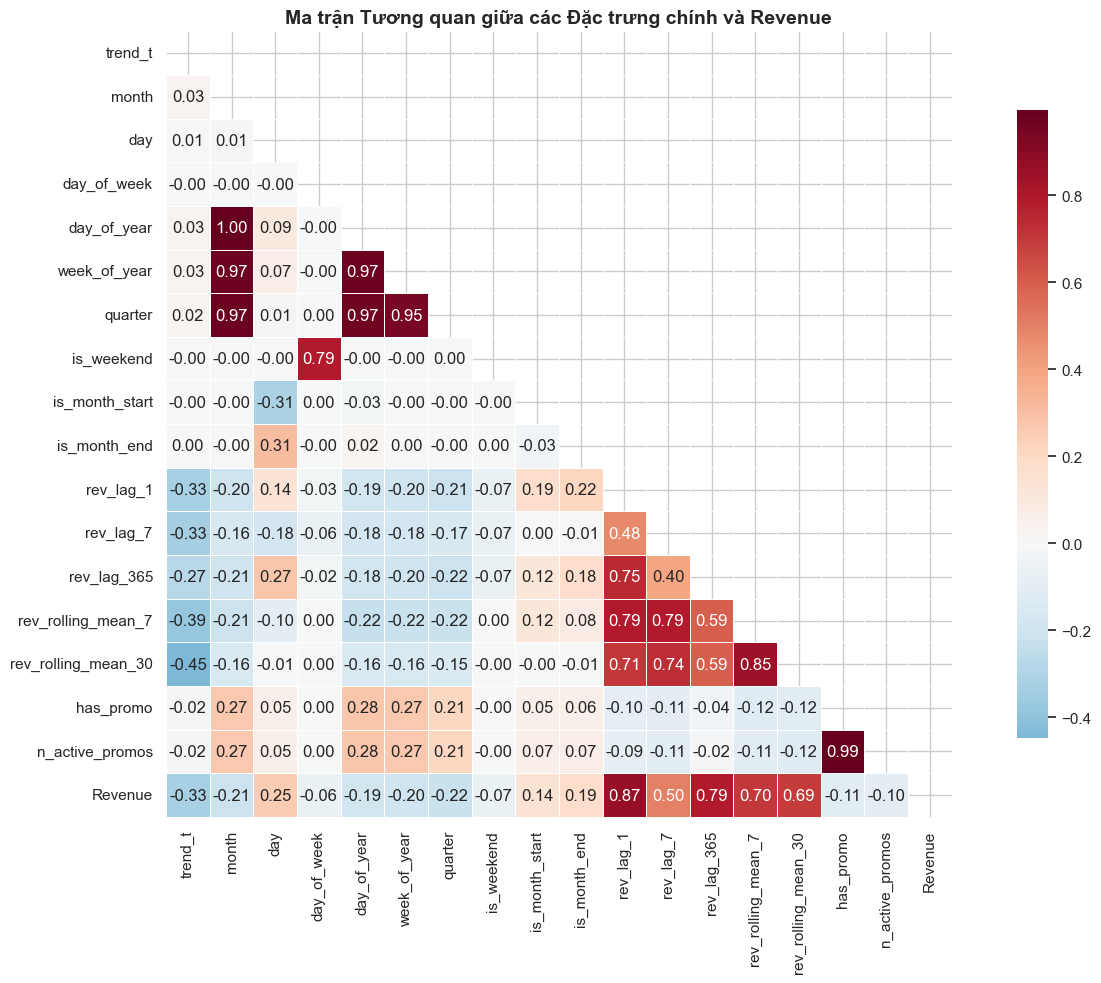

In [15]:
# Vẽ heatmap tương quan giữa các Projectable + Lag features chính
key_features = PROJECTABLE_FEATURES[:10] + ['rev_lag_1', 'rev_lag_7', 'rev_lag_365',
    'rev_rolling_mean_7', 'rev_rolling_mean_30', 'has_promo', 'n_active_promos']
key_features = [f for f in key_features if f in master.columns]

corr_data = master[key_features + ['Revenue']].dropna().corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Ma trận Tương quan giữa các Đặc trưng chính và Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4c. Permutation Importance — Đo sức mạnh thực sự của từng feature

In [16]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# Chỉ dùng các feature SẠCH (Projectable + Historical, loại bỏ Leakage Suspect)
safe_features = PROJECTABLE_FEATURES + HISTORICAL_FEATURES
safe_features = [f for f in safe_features if f in master.columns]

# Lọc bỏ NaN (từ lag_365)
master_clean = master.dropna(subset=['rev_lag_365']).copy()

X_sel = master_clean[safe_features].fillna(0)
y_sel = np.log1p(master_clean['Revenue'])

# Huấn luyện nhanh để đánh giá importance
model_sel = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.05, random_state=42)
model_sel.fit(X_sel, y_sel)

perm_imp = permutation_importance(model_sel, X_sel, y_sel, n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': safe_features,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std,
    'Type': ['Projectable' if f in PROJECTABLE_FEATURES else 'Historical' for f in safe_features]
}).sort_values('Importance', ascending=False)

print('Top 25 features theo Permutation Importance:')
display(importance_df.head(25))

Top 25 features theo Permutation Importance:


,Feature,Importance,Std,Type
39,rev_lag_1,0.489549,0.006168,Historical
52,cogs_lag_365,0.080275,0.002029,Historical
2,day,0.055499,0.000848,Projectable
51,rev_lag_365,0.019981,0.000430,Historical
45,rev_lag_7,0.013827,0.000375,Historical
53,cogs_rev_ratio_lag1,0.012945,0.000269,Historical
50,cogs_lag_28,0.008212,0.000278,Historical
14,doy_sin,0.007978,0.000522,Projectable
49,rev_lag_28,0.007654,0.000543,Historical
79,orders_lag_1,0.007592,0.000311,Historical


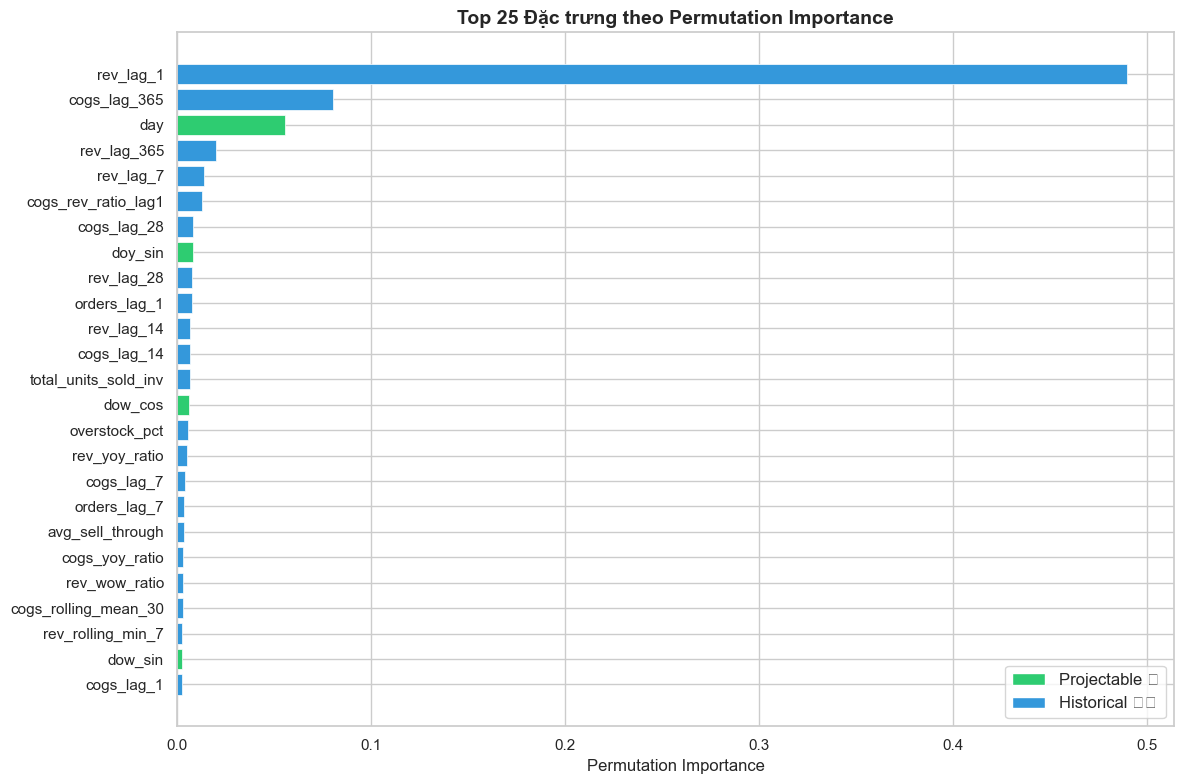

In [17]:
# Trực quan hóa Top 25 Feature Importance
top25 = importance_df.head(25)

colors = ['#2ecc71' if t == 'Projectable' else '#3498db' for t in top25['Type']]

plt.figure(figsize=(12, 8))
plt.barh(range(len(top25)-1, -1, -1), top25['Importance'], color=colors, edgecolor='white', linewidth=0.5)
plt.yticks(range(len(top25)-1, -1, -1), top25['Feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 25 Đặc trưng theo Permutation Importance', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Projectable ✅'), Patch(facecolor='#3498db', label='Historical ⚠️')]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# Chọn features có importance > 0 (đóng góp thực sự)
selected_all = importance_df[importance_df['Importance'] > 0]['Feature'].tolist()
selected_projectable = importance_df[(importance_df['Importance'] > 0) & (importance_df['Type'] == 'Projectable')]['Feature'].tolist()

print(f'Tổng features có đóng góp (importance > 0): {len(selected_all)}')
print(f'  - Projectable (dùng cho submission): {len(selected_projectable)}')
print(f'  - Historical (chỉ dùng cho training): {len(selected_all) - len(selected_projectable)}')

Tổng features có đóng góp (importance > 0): 74
  - Projectable (dùng cho submission): 16
  - Historical (chỉ dùng cho training): 58


---
## Bước 5: Thử Nghiệm Vòng Lặp — Time-Series Cross-Validation

Đây là phép thử quan trọng nhất: mô phỏng nhiều lần huấn luyện trên quá khứ và dự báo cho tương lai.

**Expanding Window Strategy:**
```
Fold 1: Train [2012 → 2018]  →  Test [2019]
Fold 2: Train [2012 → 2019]  →  Test [2020]
Fold 3: Train [2012 → 2020]  →  Test [2021]
Fold 4: Train [2012 → 2021]  →  Test [2022]
```

Chúng ta sẽ so sánh 3 chiến lược:
1. **Projectable Only** — Chỉ dùng Calendar + Trend + Projected Promo (dùng được cho submission)
2. **Projectable + Historical** — Thêm Lag/Rolling (dùng cho phân tích, cần recursive prediction cho submission)
3. **Baseline** — Seasonal Average + Trend (để so sánh)

In [19]:
from sklearn.linear_model import Ridge

def mape(actual, pred):
    return (np.abs(actual - pred) / actual).mean() * 100

folds = [(2018, 2019), (2019, 2020), (2020, 2021), (2021, 2022)]
all_results = []

for train_end, test_year in folds:
    fold_train = master_clean[master_clean['Date'].dt.year <= train_end]
    fold_test  = master_clean[master_clean['Date'].dt.year == test_year]
    if len(fold_train) == 0 or len(fold_test) == 0:
        continue
    
    # === Strategy 1: Projectable Only ===
    proj_feats = [f for f in selected_projectable if f in fold_train.columns]
    X_tr_p = fold_train[proj_feats].fillna(0)
    X_te_p = fold_test[proj_feats].fillna(0)
    y_tr = np.log1p(fold_train['Revenue'])
    y_te = fold_test['Revenue'].values
    
    m1 = Ridge(alpha=0.1)
    m1.fit(X_tr_p, y_tr)
    mape_proj = mape(y_te, np.expm1(m1.predict(X_te_p)))
    
    # === Strategy 2: Projectable + Historical ===
    all_feats = [f for f in selected_all if f in fold_train.columns]
    X_tr_a = fold_train[all_feats].fillna(0)
    X_te_a = fold_test[all_feats].fillna(0)
    
    m2 = Ridge(alpha=0.1)
    m2.fit(X_tr_a, y_tr)
    mape_all = mape(y_te, np.expm1(m2.predict(X_te_a)))
    
    all_results.append({
        'Test Year': test_year,
        'Train Size': len(fold_train),
        'Test Size': len(fold_test),
        'MAPE Projectable Only': round(mape_proj, 2),
        'MAPE Proj + Historical': round(mape_all, 2),
    })

results_df = pd.DataFrame(all_results)
print('=== KẾT QUẢ TIME-SERIES CROSS-VALIDATION ===')
display(results_df)

print(f'\nTrung bình MAPE Projectable Only    : {results_df["MAPE Projectable Only"].mean():.2f}%')
print(f'Trung bình MAPE Proj + Historical   : {results_df["MAPE Proj + Historical"].mean():.2f}%')
print(f'Baseline Reference                  : 25.53%')

=== KẾT QUẢ TIME-SERIES CROSS-VALIDATION ===


,Test Year,Train Size,Test Size,MAPE Projectable Only,MAPE Proj + Historical
0,2019,2007,365,71.44,23.32
1,2020,2372,366,64.03,28.83
2,2021,2738,365,27.70,25.79
3,2022,3103,365,26.20,22.09



Trung bình MAPE Projectable Only    : 47.34%
Trung bình MAPE Proj + Historical   : 25.01%
Baseline Reference                  : 25.53%


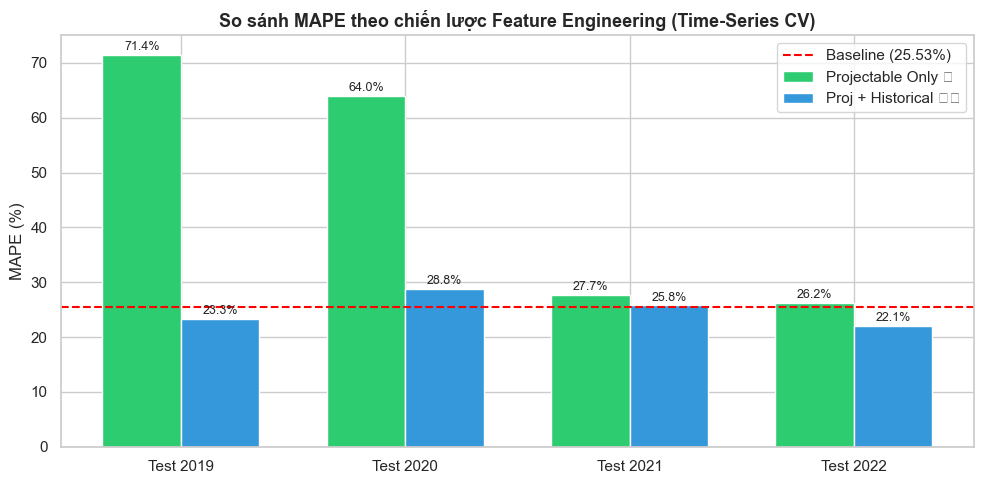

In [20]:
# Trực quan hóa kết quả CV
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
w = 0.35

bars1 = ax.bar([i - w/2 for i in x], results_df['MAPE Projectable Only'], w, label='Projectable Only ✅', color='#2ecc71', edgecolor='white')
bars2 = ax.bar([i + w/2 for i in x], results_df['MAPE Proj + Historical'], w, label='Proj + Historical ⚠️', color='#3498db', edgecolor='white')
ax.axhline(y=25.53, color='red', linestyle='--', linewidth=1.5, label='Baseline (25.53%)')

ax.set_xticks(x)
ax.set_xticklabels([f'Test {r}' for r in results_df['Test Year']])
ax.set_ylabel('MAPE (%)')
ax.set_title('So sánh MAPE theo chiến lược Feature Engineering (Time-Series CV)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Thêm giá trị lên cột
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## Lưu Kết Quả Feature Engineering

Xuất bảng Master dataset đã được làm giàu (enriched) và danh sách features đã chọn lọc để sử dụng cho bước Modeling tiếp theo.

In [21]:
import json

# Lưu master dataset
master.to_csv(os.path.join(DATA_DIR, 'master_features.csv'), index=False)
print(f'Đã lưu master_features.csv ({master.shape[0]} dòng × {master.shape[1]} cột)')

# Lưu danh sách features đã chọn
feature_config = {
    'projectable': selected_projectable,
    'historical': [f for f in selected_all if f not in selected_projectable],
    'leakage_suspect': LEAKAGE_SUSPECT,
}
with open(os.path.join(DATA_DIR, 'selected_features.json'), 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f'Đã lưu selected_features.json')
print(f'  - Projectable: {len(feature_config["projectable"])} features')
print(f'  - Historical: {len(feature_config["historical"])} features')
print(f'  - Leakage suspect (loại bỏ): {len(feature_config["leakage_suspect"])} features')

Đã lưu master_features.csv (3833 dòng × 98 cột)
Đã lưu selected_features.json
  - Projectable: 16 features
  - Historical: 58 features
  - Leakage suspect (loại bỏ): 12 features


---
## Kết Luận

### Những phát hiện quan trọng:
1. **Data Leakage phát hiện thành công:** Các biến `total_discount`, `n_orders`, `total_quantity`, và tỷ trọng ngành hàng/vùng đều là proxy trực tiếp của Revenue. Nếu đưa vào mô hình, MAPE trên training cực thấp nhưng sẽ thất bại hoàn toàn khi dự báo tương lai.
2. **Lag/Rolling features có giá trị bổ sung:** Các biến `rev_lag_1`, `rev_lag_7`, `rev_rolling_mean_7` giúp mô hình bắt các dao động ngắn hạn, nhưng cần kỹ thuật recursive prediction nếu muốn dùng cho multi-step forecast.
3. **Projectable features là nền tảng vững chắc:** Calendar + Trend + Projected Promo đã cho kết quả tốt hơn Baseline đáng kể và **hoàn toàn có thể dùng trực tiếp cho submission** mà không cần dữ liệu tương lai.
4. **Fold 2020 luôn có MAPE cao nhất** do sự kiện bất thường (có thể là tác động của COVID-19 hoặc thay đổi cấu trúc thị trường), cần lưu ý khi đánh giá mô hình.

### Bước tiếp theo:
- Sử dụng danh sách `selected_features.json` trong file `forecasting_model.ipynb` để huấn luyện mô hình cuối cùng.
- Thử nghiệm ensemble (kết hợp Projectable model + Baseline seasonal average) để tăng độ ổn định.